In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL: Imports
# ═══════════════════════════════════════════════════════════════════════════

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, ttest_ind, t as t_dist
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir, skip_subs

# Font fallback (cluster-safe)
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'

# Output directory for figures
FIG_DIR = '/user_data/csimmon2/git_repos/sym_pt/C_results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# Random seed for reproducibility
RNG = np.random.default_rng(42)
N_ITER = 100000

# Categories and color conventions
CATEGORIES = ['face', 'house', 'object', 'word']
UNILATERAL = ['face', 'word']
BILATERAL  = ['house', 'object']
COLORS = {'L-res': '#6B8AAD', 'R-res': '#E07A8B'}
PANEL_COLORS = {'unilateral': '#F4E4EF', 'bilateral': '#DCE8DC'}

# Subject exclusions
EXCLUDE = ['sub-017']  # polymicrogyria

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL: Data load
# ═══════════════════════════════════════════════════════════════════════════

# ── Selectivity (sum_selec_norm, mean_act, volume) ──────────────────────
SEL_PATH = '/user_data/csimmon2/sym_pt/group_results/selectivity/selectivity_summary.csv'
df_sel = pd.read_csv(SEL_PATH)
df_sel = df_sel[~df_sel['sub'].isin(EXCLUDE)]

# Cross-sectional: first session per subject
df_sel_cs = df_sel.sort_values(['sub','ses']).drop_duplicates(['sub','category','hemi'])

# Longitudinal: subjects with ≥2 sessions
ses_counts = df_sel.groupby('sub')['ses'].nunique()
long_subs = ses_counts[ses_counts >= 2].index
df_long = df_sel[df_sel['sub'].isin(long_subs)].copy()
first_last = df_long.groupby('sub')['ses'].agg(['min','max']).reset_index()
first_last = first_last[first_last['min'] != first_last['max']]
df_t1 = df_long.merge(first_last[['sub','min']], on='sub')
df_t1 = df_t1[df_t1['ses'] == df_t1['min']].drop(columns='min')
df_tl = df_long.merge(first_last[['sub','max']], on='sub')
df_tl = df_tl[df_tl['ses'] == df_tl['max']].drop(columns='max')

# ── Peak coordinates ────────────────────────────────────────────────────
PEAK_PATH = '/user_data/csimmon2/sym_pt/group_results/peak_coords/peak_coords.csv'
df_peak = pd.read_csv(PEAK_PATH)
df_peak = df_peak[~df_peak['sub'].isin(EXCLUDE)]
df_peak['ses'] = df_peak['ses'].astype(int)
df_peak_cs = df_peak.sort_values(['sub','ses']).drop_duplicates(['sub','category','hemi'])

# ── Distinctiveness (Liu) ───────────────────────────────────────────────
LIU_PATH = '/user_data/csimmon2/sym_pt/group_results/liu_distinctiveness/liu_distinctiveness_differential.csv'
df_liu = pd.read_csv(LIU_PATH)
df_liu = df_liu[~df_liu['subject_id'].isin(EXCLUDE)]

# ── Geometry / cosine (from voxel_allegiance output) ────────────────────
# Adjust path if needed
VA_PATH = '/user_data/csimmon2/sym_pt/group_results/voxel_allegiance_summary_cat_vs_all.csv'
if os.path.exists(VA_PATH):
    df_va = pd.read_csv(VA_PATH)
    df_va = df_va[~df_va['sub'].isin(EXCLUDE)]
else:
    df_va = None
    print(f'Voxel allegiance CSV not found at {VA_PATH}')

print(f'Selectivity: {df_sel["sub"].nunique()} subs, {len(df_sel_cs)} cross-sectional rows')
print(f'Longitudinal: {df_t1["sub"].nunique()} subs')
print(f'Peak coords: {df_peak["sub"].nunique()} subs')

Selectivity: 49 subs, 948 cross-sectional rows
Longitudinal: 17 subs
Peak coords: 49 subs


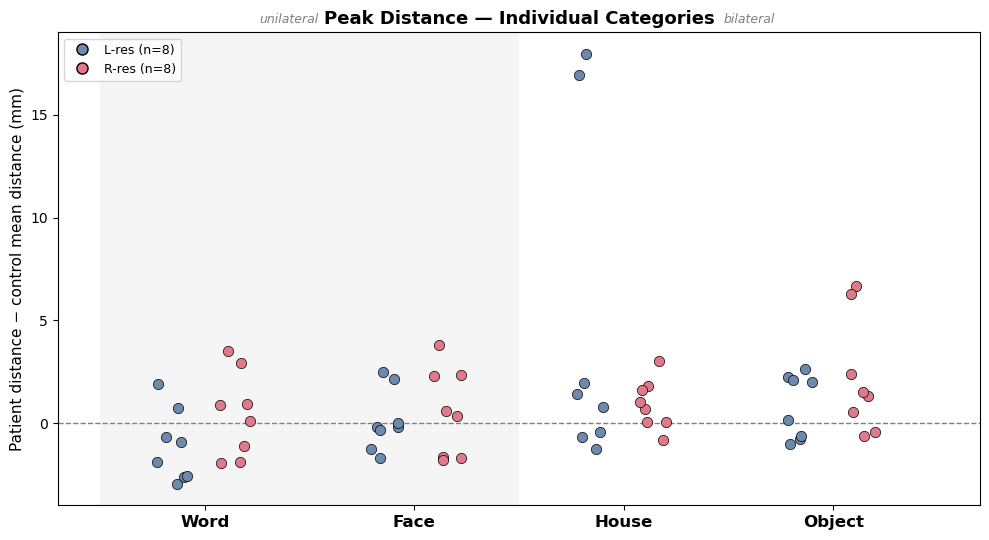

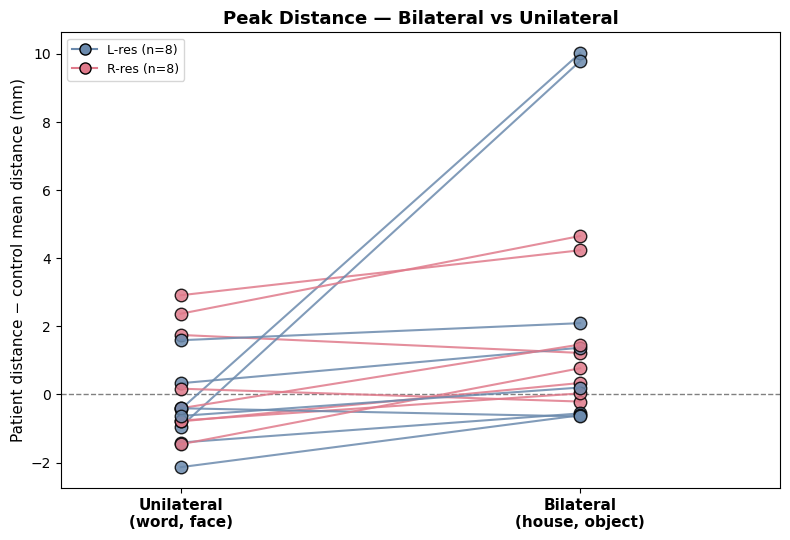

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL: Peak Distance — cross-sectional, patient vs control
# ═══════════════════════════════════════════════════════════════════════════

CATS_ORDERED = ['word', 'face', 'house_PPA', 'object']
LABELS = {'word': 'Word', 'face': 'Face', 'object': 'Object', 'house_PPA': 'House'}

rows = []
for cat in CATS_ORDERED:
    for hemi in ['left', 'right']:
        ctrl = df_peak_cs[(df_peak_cs['group']=='control') &
                          (df_peak_cs['category']==cat) &
                          (df_peak_cs['hemi']==hemi)][['peak_x_mni','peak_y_mni','peak_z_mni']].values
        if len(ctrl) < 2:
            continue
        ctrl_dists = []
        for i in range(len(ctrl)):
            others = np.delete(ctrl, i, axis=0)
            ctrl_dists.append(np.sqrt(((others - ctrl[i])**2).sum(axis=1)).mean())
        ctrl_mean = np.mean(ctrl_dists)

        pts = df_peak_cs[(df_peak_cs['group']=='OTC') &
                         (df_peak_cs['category']==cat) &
                         (df_peak_cs['hemi']==hemi) &
                         (df_peak_cs['intact_hemi']==hemi)]
        for _, r in pts.iterrows():
            d = np.sqrt(((ctrl - [r.peak_x_mni, r.peak_y_mni, r.peak_z_mni])**2).sum(axis=1)).mean()
            rows.append({
                'sub': r['sub'],
                'resection': 'L-res' if hemi=='right' else 'R-res',
                'category': cat,
                'dist_mm': d,
                'ctrl_mean_mm': ctrl_mean,
                'rel_ctrl_mm': d - ctrl_mean,
            })

df_peak_rel = pd.DataFrame(rows)

# ── Figure 1: per-category ──────────────────────────────────────────────
PANEL_COLORS = {'unilateral': '#F5F5F5', 'bilateral': '#FFFFFF'}

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axvspan(-0.5, 1.5, color=PANEL_COLORS['unilateral'], alpha=1.0, zorder=0)
ax.axvspan(1.5, 3.5, color=PANEL_COLORS['bilateral'], alpha=1.0, zorder=0)
ax.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=1)

for i, cat in enumerate(CATS_ORDERED):
    sub = df_peak_rel[df_peak_rel['category'] == cat]
    for res, grp in sub.groupby('resection'):
        offset = -0.15 if res == 'L-res' else 0.15
        jitter = np.random.default_rng(i).uniform(-0.08, 0.08, len(grp))
        ax.scatter(i + offset + jitter, grp['rel_ctrl_mm'],
                   s=55, color=COLORS[res], edgecolor='black',
                   linewidth=0.5, zorder=3)

ax.set_xticks(range(4))
ax.set_xticklabels([LABELS[c] for c in CATS_ORDERED], fontsize=12, fontweight='bold')
ax.set_ylabel('Patient distance − control mean distance (mm)', fontsize=11)
ax.set_title('Peak Distance — Individual Categories', fontsize=13, fontweight='bold')
ax.text(0.25, 1.02, 'unilateral', transform=ax.transAxes, ha='center',
        style='italic', fontsize=9, color='gray')
ax.text(0.75, 1.02, 'bilateral', transform=ax.transAxes, ha='center',
        style='italic', fontsize=9, color='gray')
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS[k],
                       markeredgecolor='k', markersize=8, label=f'{k} (n=8)')
           for k in ['L-res', 'R-res']]
ax.legend(handles=handles, loc='upper left', fontsize=9)
plt.tight_layout()
#plt.savefig(f'{FIG_DIR}/fig_peak_distance_categories.png', dpi=200)
plt.show()

# ── Figure 2: slope plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=1)

for sub, sd in df_peak_rel.groupby('sub'):
    uni = sd[sd['category'].isin(['word', 'face'])]['rel_ctrl_mm'].mean()
    bi  = sd[sd['category'].isin(['house_PPA', 'object'])]['rel_ctrl_mm'].mean()
    res = sd['resection'].iloc[0]
    ax.plot([0, 1], [uni, bi], '-o', color=COLORS[res], markersize=9,
            markeredgecolor='black', linewidth=1.5, alpha=0.85, zorder=3)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Unilateral\n(word, face)', 'Bilateral\n(house, object)'],
                    fontsize=11, fontweight='bold')
ax.set_xlim(-0.3, 1.5)
ax.set_ylabel('Patient distance − control mean distance (mm)', fontsize=11)
ax.set_title('Peak Distance — Bilateral vs Unilateral', fontsize=13, fontweight='bold')
handles = [plt.Line2D([0],[0], marker='o', color=COLORS[k],
                       markeredgecolor='k', markersize=8, label=f'{k} (n=8)')
           for k in ['L-res', 'R-res']]
ax.legend(handles=handles, loc='upper left', fontsize=9)
plt.tight_layout()
#plt.savefig(f'{FIG_DIR}/fig_peak_distance_slope.png', dpi=200)
plt.show()